<a href="https://colab.research.google.com/github/NeuralStrum/youtwilly/blob/main/using%20gru.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
import os

# Define the destination directory
trade_data_dir = '/content/trade_data'

# Create the directory if it doesn't exist
if not os.path.exists(trade_data_dir):
    os.makedirs(trade_data_dir)

# Unzip the file into the new directory
unzip_command = f'unzip -o /content/drive/MyDrive/RawData.zip -d {trade_data_dir}'
!{unzip_command}

# List the contents of the new directory to verify
print(f'\nContents of {trade_data_dir}:')
!ls {trade_data_dir}

import pandas as pd

# Construct the full path to th|e CSV file
csv_file_path = os.path.join(trade_data_dir, 'RawData.csv')

# Load the CSV file into a pandas DataFrame
df = pd.read_csv(csv_file_path)

# Display the first 5 rows of the DataFrame
display(df.head())

Archive:  /content/drive/MyDrive/RawData.zip
  inflating: /content/trade_data/RawData.csv  

Contents of /content/trade_data:
RawData.csv


,Time,Open,High,Low,Close,Volume
0,5/19/2025 10:54:00 PM,3232.53,3233.51,3232.45,3233.29,134
1,5/19/2025 10:55:00 PM,3233.29,3234.18,3233.29,3234.14,77
2,5/19/2025 10:56:00 PM,3234.14,3234.14,3233.79,3234.03,93
3,5/19/2025 10:57:00 PM,3234.03,3234.46,3233.97,3233.98,112
4,5/19/2025 10:58:00 PM,3233.98,3234.16,3233.77,3233.96,100


In [6]:
import numpy as np

# Ensure 'Time' column is datetime and set as index for resampling
df['Time'] = pd.to_datetime(df['Time'])
df_raw_resample = df.set_index('Time')

# Define rsi_timeframes
rsi_timeframes = {
    '1min': '1min',
    '5min': '5min',
    '15min': '15min',
    '30min': '30min',
    '1h': '1H',
    '4h': '4H',
    '1d': '1D'
}

def backtest_filtered_supertrend(data, st_period=10, st_mult=3, rsi_period=14, trade_quantity=1.0):
    df_fs = data.copy()

    # Supertrend components
    high_low = df_fs['High'] - df_fs['Low']
    high_close = (df_fs['High'] - df_fs['Close'].shift()).abs()
    low_close = (df_fs['Low'] - df_fs['Close'].shift()).abs()
    atr = pd.concat([high_low, high_close, low_close], axis=1).max(axis=1).rolling(st_period).mean()
    hl2 = (df_fs['High'] + df_fs['Low']) / 2
    upper = hl2 + (st_mult * atr)
    lower = hl2 - (st_mult * atr)

    # RSI component
    delta = df_fs['Close'].diff()
    gain = (delta.where(delta > 0, 0)).rolling(window=rsi_period).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(window=rsi_period).mean()
    df_fs['RSI'] = 100 - (100 / (1 + (gain / loss)))

    # Trend Logic
    trend = np.ones(len(df_fs))
    close_v = df_fs['Close'].values
    up_v = upper.values
    lo_v = lower.values
    for i in range(1, len(df_fs)):
        if close_v[i] > up_v[i-1]: trend[i] = 1
        elif close_v[i] < lo_v[i-1]: trend[i] = -1
        else: trend[i] = trend[i-1]

    df_fs['Trend'] = trend
    df_fs.dropna(inplace=True)

    balance = 100000.0
    # position_quantity now represents the quantity of assets held, not just a boolean state
    position_quantity = 0
    entry_price_per_unit = 0.0 # To store the price per unit at entry
    trades = 0

    t_vals = df_fs['Trend'].values
    r_vals = df_fs['RSI'].values
    c_vals = df_fs['Close'].values

    for i in range(1, len(df_fs)):
        # Buy: Trend flips to 1 AND RSI > 50
        if position_quantity == 0 and t_vals[i] == 1 and t_vals[i-1] == -1 and r_vals[i] > 50:
            balance -= 0.3 # Commission for buying
            entry_price_per_unit = c_vals[i]
            position_quantity = trade_quantity # Set position to the desired quantity
            balance -= entry_price_per_unit * position_quantity # Deduct total cost of position
            trades += 1
        # Exit: Trend flips to -1
        elif position_quantity > 0 and t_vals[i] == -1:
            balance += c_vals[i] * position_quantity # Add sale proceeds to balance
            balance -= 0.3 # Commission for selling
            position_quantity = 0 # Close position

    # If position is still open at the end, close it at the last price
    if position_quantity > 0:
        balance += c_vals[-1] * position_quantity
        balance -= 0.3 # Final commission for closing

    return {'Strategy': 'Filtered Supertrend', 'Trades': trades, 'NetProfit': round(balance - 100000.0, 2)}

fs_results = []

# Run backtest only for '5min' timeframe as requested
label = '5min'
offset = rsi_timeframes[label]

if offset == '1min':
    resampled_tf = df_raw_resample[['Open', 'High', 'Low', 'Close']].copy()
else:
    resampled_tf = df_raw_resample[['Open', 'High', 'Low', 'Close']].resample(offset).agg({'Open':'first', 'High':'max', 'Low':'min', 'Close':'last'}).dropna()

# Call the backtesting function with trade_quantity = 0.01
res = backtest_filtered_supertrend(resampled_tf, trade_quantity=0.01)
res['Timeframe'] = label
fs_results.append(res)

fs_comparison_df = pd.DataFrame(fs_results)
display(fs_comparison_df)

/tmp/ipykernel_16249/630560085.py:4: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Time'] = pd.to_datetime(df['Time'])


,Strategy,Trades,NetProfit,Timeframe
0,Filtered Supertrend,81,-40.4,5min


## GRU Model for Time Series Forecasting

First, we'll import the necessary libraries, scale the data, and prepare it into sequences for the GRU model. We'll use a 70% train, 10% validation, and 20% test split.

In [10]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GRU, Dense, Dropout
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
import numpy as np # Ensure numpy is imported here if not globally available
import pandas as pd # Import pandas

# Ensure 'Time' column is datetime and set as index for resampling
# Assuming 'df' is loaded from a previous cell.
# If 'df' is not defined, please ensure the first data loading cell (_P4lGyAXoOVj) is run.

df['Time'] = pd.to_datetime(df['Time'])
df_raw_resample = df.set_index('Time')

# Define rsi_timeframes (needed for 'offset')
rsi_timeframes = {
    '1min': '1min',
    '5min': '5min',
    '15min': '15min',
    '30min': '30min',
    '1h': '1H',
    '4h': '4H',
    '1d': '1D'
}

# Derive resampled_tf for 5-min timeframe, as per previous instruction
label = '5min'
offset = rsi_timeframes[label]

if offset == '1min':
    resampled_tf = df_raw_resample[['Open', 'High', 'Low', 'Close']].copy()
else:
    resampled_tf = df_raw_resample[['Open', 'High', 'Low', 'Close']].resample(offset).agg({'Open':'first', 'High':'max', 'Low':'min', 'Close':'last'}).dropna()

# Select features for training. 'Close' price is usually the target.
features = ['Open', 'High', 'Low', 'Close']
data_to_scale = resampled_tf[features].values # Use the corrected resampled_tf

# Scale the data
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(data_to_scale)

# Define the number of future steps to predict
N_PREDICT_STEPS = 10

# Define sequence creation function
def create_sequences(data, seq_length, n_predict_steps=N_PREDICT_STEPS):
    X, y = [], []
    for i in range(len(data) - seq_length - n_predict_steps + 1):
        X.append(data[i:i + seq_length])
        y.append(data[i + seq_length : i + seq_length + n_predict_steps, features.index('Close')]) # Predict the next N_PREDICT_STEPS 'Close' prices
    return np.array(X), np.array(y)

# Define sequence length
SEQ_LENGTH = 60 # Using 60 timesteps (e.g., 60 minutes for 1-min data) as input

X, y = create_sequences(scaled_data, SEQ_LENGTH, N_PREDICT_STEPS)

# Split data: 70% train, 10% validation, 20% test
# First, split into training + validation and test
X_train_val, X_test, y_train_val, y_test = train_test_split(X, y, test_size=0.2, random_state=42, shuffle=False)

# Then, split training + validation into training and validation (10% of total for validation)
val_size = int(len(X) * 0.1)
X_train, X_val, y_train, y_val = train_test_split(X_train_val, y_train_val, test_size=val_size / len(X_train_val), random_state=42, shuffle=False)

print(f"X_train shape: {X_train.shape}, y_train shape: {y_train.shape}")
print(f"X_val shape: {X_val.shape}, y_val shape: {y_val.shape}")
print(f"X_test shape: {X_test.shape}, y_test shape: {y_test.shape}")

X_train shape: (49469, 60, 4), y_train shape: (49469, 10)
X_val shape: (7067, 60, 4), y_val shape: (7067, 10)
X_test shape: (14134, 60, 4), y_test shape: (14134, 10)


### Build the GRU Model

Now, let's define the architecture of our GRU model.

In [11]:
from tensorflow.keras.layers import GRU, Dense, Dropout, BatchNormalization, Input
from tensorflow.keras.callbacks import LearningRateScheduler

def lr_schedule(epoch):
    lr = 1e-3
    if epoch > 10:
        lr *= 0.1
    return lr

model = Sequential([
    Input(shape=(X_train.shape[1], X_train.shape[2])),
    GRU(units=100, return_sequences=True),
    BatchNormalization(),
    Dropout(0.2),
    GRU(units=100, return_sequences=True),
    BatchNormalization(),
    Dropout(0.2),
    GRU(units=50, return_sequences=False),
    BatchNormalization(),
    Dropout(0.2),
    Dense(units=N_PREDICT_STEPS)
])

optimizer = tf.keras.optimizers.Adam(learning_rate=1e-3)
model.compile(optimizer=optimizer, loss='mse')
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru_2 (GRU)                     │ (None, 60, 50)         │         8,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 60, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_3 (GRU)                     │ (None, 50)             │        15,300 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           510 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,210 (94.57 KB)

 Trainable params: 24,210 (94.57 KB)

 Non-trainable params: 0 (0.00 B)

### Train the GRU Model

Finally, we'll train the model using the prepared training and validation data.

1546/1546 ━━━━━━━━━━━━━━━━━━━━ 131s 83ms/step - loss: 0.0021 - val_loss: 1.1745e-04


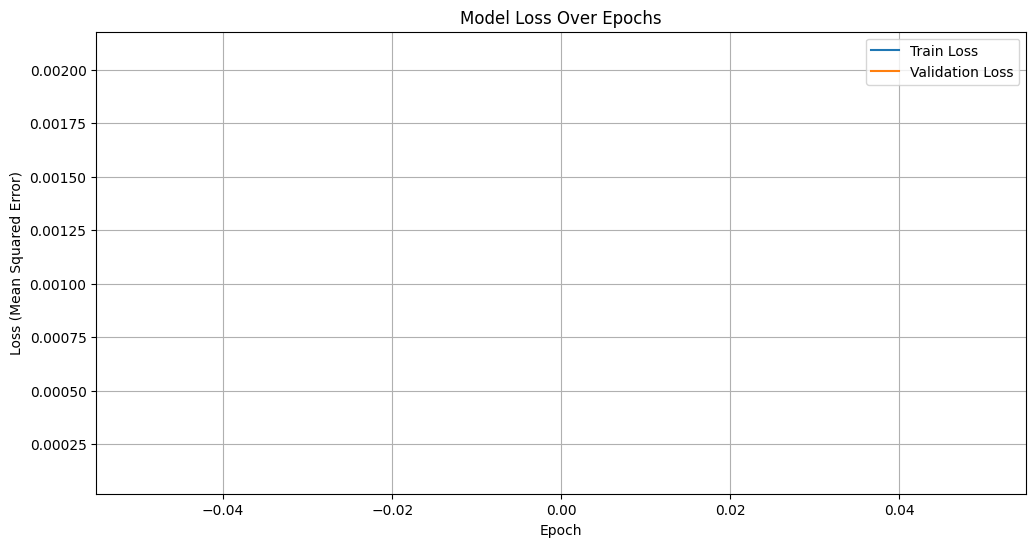

In [12]:
lr_callback = LearningRateScheduler(lr_schedule)

history = model.fit(
    X_train,
    y_train,
    epochs=5, # Increased to 5 epochs for a 'better' result, though 20+ is ideal
    batch_size=64,
    validation_data=(X_val, y_val),
    callbacks=[lr_callback],
    verbose=1
)

# Plot training history
plt.figure(figsize=(12, 6))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Improved Model Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.grid(True)
plt.show()

### Make Predictions and Inverse Scale

In [13]:
from sklearn.preprocessing import MinMaxScaler

# Make predictions on the test set
predictions = model.predict(X_test)

# Inverse transform the predictions and actual values
# To inverse transform, we need to create a dummy array with the same shape as scaled_data
# and place the predictions/y_test values into the 'Close' column index.

# For predictions
predictions_full_scale = np.zeros((predictions.shape[0], N_PREDICT_STEPS, scaled_data.shape[1]))
predictions_full_scale[:, :, features.index('Close')] = predictions
predictions_original_scale = scaler.inverse_transform(predictions_full_scale.reshape(-1, scaled_data.shape[1])).reshape(predictions.shape[0], N_PREDICT_STEPS, scaled_data.shape[1])
predicted_close_prices = predictions_original_scale[:, :, features.index('Close')]

# For y_test (actual values)
y_test_full_scale = np.zeros((y_test.shape[0], N_PREDICT_STEPS, scaled_data.shape[1]))
y_test_full_scale[:, :, features.index('Close')] = y_test
y_test_original_scale = scaler.inverse_transform(y_test_full_scale.reshape(-1, scaled_data.shape[1])).reshape(y_test.shape[0], N_PREDICT_STEPS, scaled_data.shape[1])
actual_close_prices = y_test_original_scale[:, :, features.index('Close')]

print(f"Shape of predicted_close_prices: {predicted_close_prices.shape}")
print(f"Shape of actual_close_prices: {actual_close_prices.shape}")

442/442 ━━━━━━━━━━━━━━━━━━━━ 7s 15ms/step
Shape of predicted_close_prices: (14134, 10)
Shape of actual_close_prices: (14134, 10)


### Plot Predictions

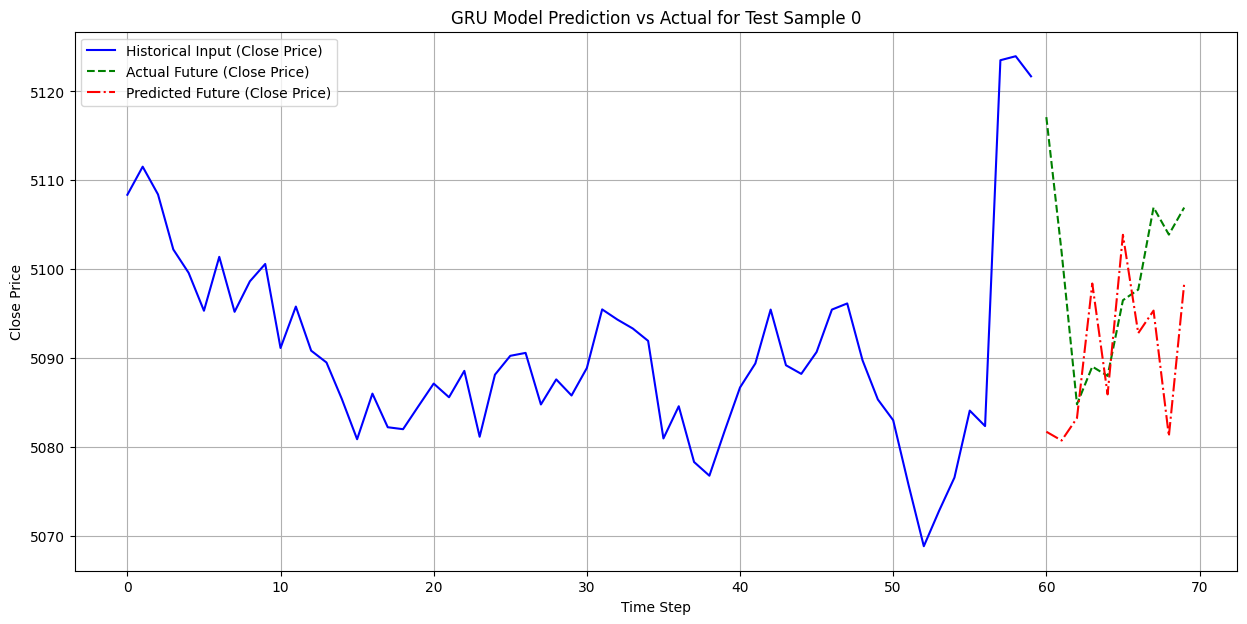

In [14]:
import matplotlib.pyplot as plt

# Choose a sample from the test set to plot
sample_index = 0 # You can change this index to view different samples

# Get the last input sequence for the chosen sample (from X_test)
# We need to inverse transform the input sequence to show it on the same scale as predictions
input_sequence_scaled = X_test[sample_index]
input_sequence_full_scale = np.zeros((input_sequence_scaled.shape[0], scaled_data.shape[1]))
input_sequence_full_scale[:, :] = input_sequence_scaled
input_sequence_original_scale = scaler.inverse_transform(input_sequence_full_scale)
input_close_prices = input_sequence_original_scale[:, features.index('Close')]

# Get the actual and predicted future prices for the chosen sample
actual_future_prices = actual_close_prices[sample_index]
predicted_future_prices = predicted_close_prices[sample_index]

# Create time indices for plotting
input_time_indices = np.arange(SEQ_LENGTH)
future_time_indices = np.arange(SEQ_LENGTH, SEQ_LENGTH + N_PREDICT_STEPS)

plt.figure(figsize=(15, 7))

# Plot the historical input data
plt.plot(input_time_indices, input_close_prices, label='Historical Input (Close Price)', color='blue')

# Plot the actual future data
plt.plot(future_time_indices, actual_future_prices, label='Actual Future (Close Price)', color='green', linestyle='--')

# Plot the predicted future data
plt.plot(future_time_indices, predicted_future_prices, label='Predicted Future (Close Price)', color='red', linestyle='-.')

plt.title(f'GRU Model Prediction vs Actual for Test Sample {sample_index}')
plt.xlabel('Time Step')
plt.ylabel('Close Price')
plt.legend()
plt.grid(True)
plt.show()


### Evaluate on Validation Set
We will now run the same prediction and plotting logic on the validation set (`X_val`) to compare results.

221/221 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step


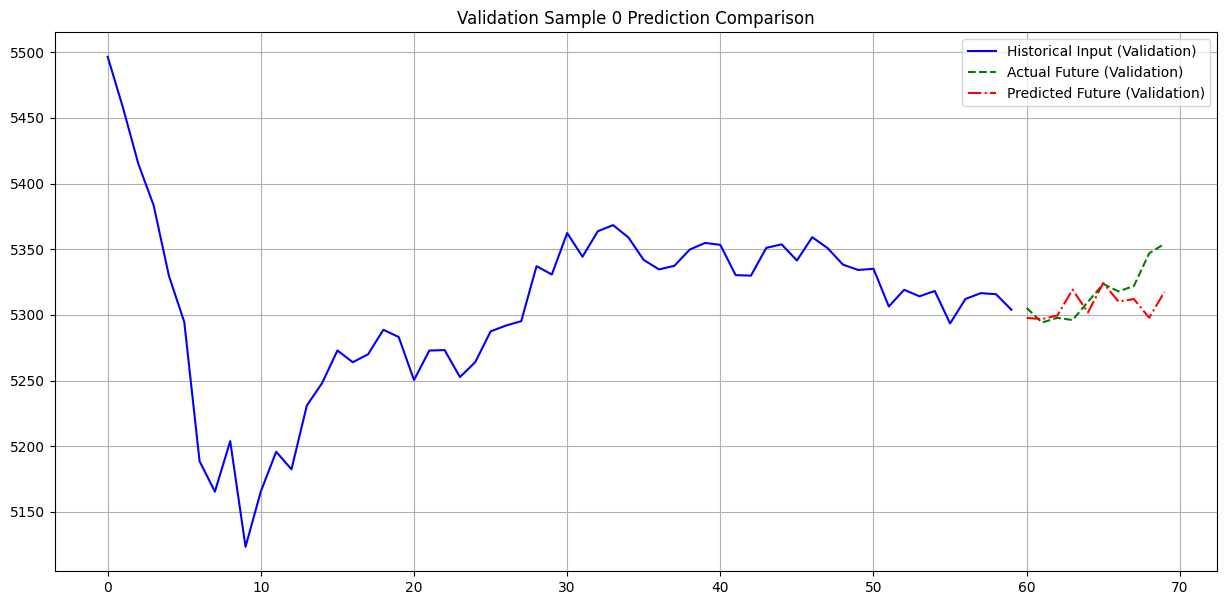

In [15]:
import numpy as np
import matplotlib.pyplot as plt

# Make predictions on the validation set
val_predictions = model.predict(X_val)

# Inverse transform the validation predictions
val_predictions_full = np.zeros((val_predictions.shape[0], N_PREDICT_STEPS, scaled_data.shape[1]))
val_predictions_full[:, :, features.index('Close')] = val_predictions
val_predictions_orig = scaler.inverse_transform(val_predictions_full.reshape(-1, scaled_data.shape[1])).reshape(val_predictions.shape[0], N_PREDICT_STEPS, scaled_data.shape[1])
val_predicted_close = val_predictions_orig[:, :, features.index('Close')]

# Inverse transform the validation actuals (y_val)
y_val_full = np.zeros((y_val.shape[0], N_PREDICT_STEPS, scaled_data.shape[1]))
y_val_full[:, :, features.index('Close')] = y_val
y_val_orig = scaler.inverse_transform(y_val_full.reshape(-1, scaled_data.shape[1])).reshape(y_val.shape[0], N_PREDICT_STEPS, scaled_data.shape[1])
val_actual_close = y_val_orig[:, :, features.index('Close')]

# Plot a sample from validation set
sample_idx_val = 0
input_seq_val_scaled = X_val[sample_idx_val]
input_seq_val_full = np.zeros((input_seq_val_scaled.shape[0], scaled_data.shape[1]))
input_seq_val_full[:, :] = input_seq_val_scaled
input_seq_val_orig = scaler.inverse_transform(input_seq_val_full)
input_val_close = input_seq_val_orig[:, features.index('Close')]

plt.figure(figsize=(15, 7))
plt.plot(np.arange(SEQ_LENGTH), input_val_close, label='Historical Input (Validation)', color='blue')
plt.plot(np.arange(SEQ_LENGTH, SEQ_LENGTH + N_PREDICT_STEPS), val_actual_close[sample_idx_val], label='Actual Future (Validation)', color='green', linestyle='--')
plt.plot(np.arange(SEQ_LENGTH, SEQ_LENGTH + N_PREDICT_STEPS), val_predicted_close[sample_idx_val], label='Predicted Future (Validation)', color='red', linestyle='-.')
plt.title(f'Validation Sample {sample_idx_val} Prediction Comparison')
plt.legend()
plt.grid(True)
plt.show()